<a href="https://colab.research.google.com/github/khoirul2003/PVCK_Ganjil_2025/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Praktikum**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


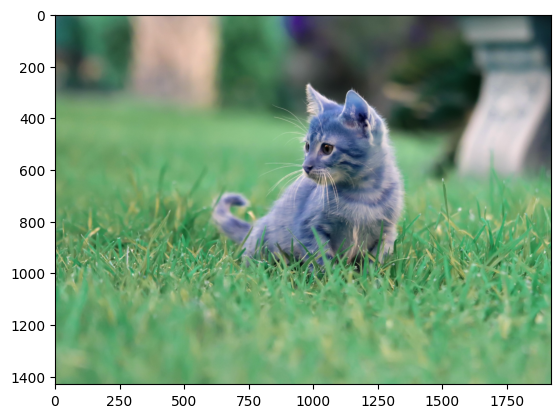

In [3]:

import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('/content/drive/MyDrive/Images/kitten.jpg')
plt.imshow(img) #perhatikan hasilnya adalah citra dgn channel warna BGR


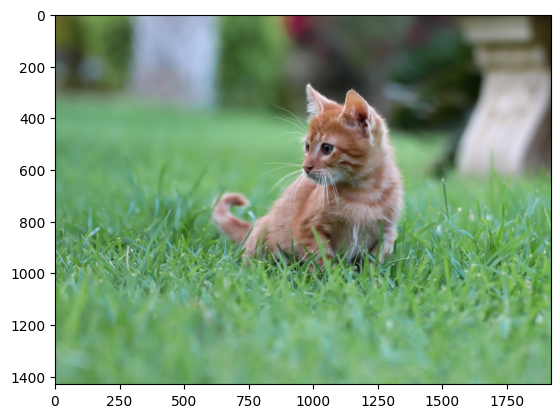

In [ ]:
img2 = img
img3 = cv.cvtColor(img, cv.COLOR_BGR2RGB) #konversi channel BGR -> RGB
plt.imshow(img3)

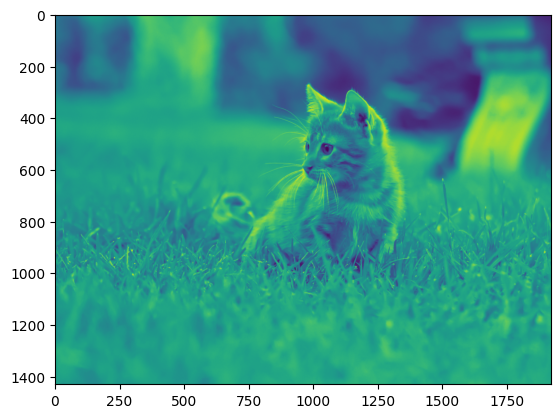

In [ ]:
img_gray = cv.imread('/content/drive/MyDrive/Images/kitten.jpg', cv.IMREAD_GRAYSCALE)
plt.imshow(img_gray)

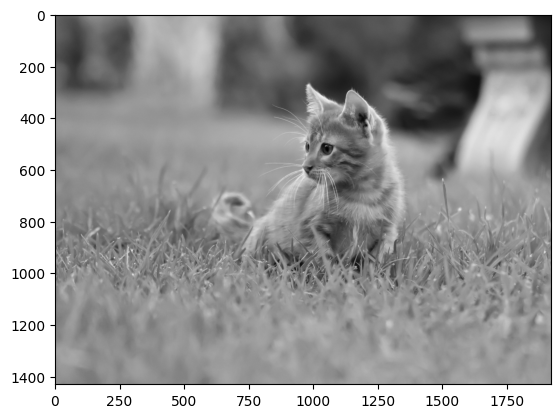

In [ ]:
plt.imshow(img_gray, cmap='gray')


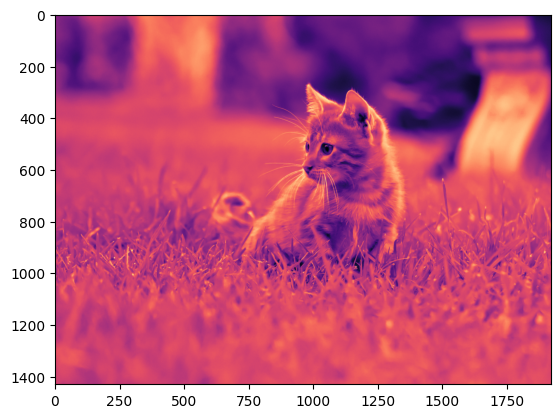

In [ ]:
plt.imshow(img_gray, cmap='magma')

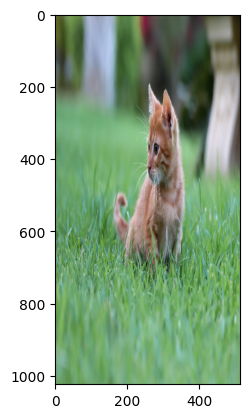

In [ ]:
img4 = cv.resize(cv.cvtColor(img, cv.COLOR_BGR2RGB), (512, 1024))
plt.imshow(img4)

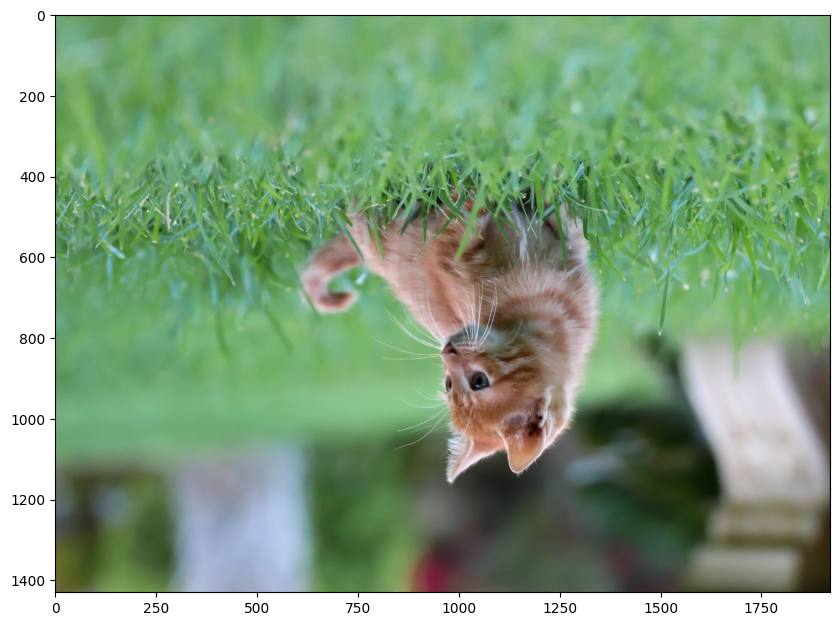

In [ ]:
img5 = cv.flip(cv.cvtColor(img, cv.COLOR_BGR2RGB), 0)

#simpan File image
#cv.imwrite('/content/drive/MyDrive/PCVK_MW/Images/mandrill2.tiff', img5)

#tampilkan plot dengan ukuran canvas yg lebih besar
fig = plt.figure(figsize=(10,10)) #ubah-ubah ukuran (10,10) sesuai kebutuhan
ax = fig.add_subplot(111)
ax.imshow(img5)


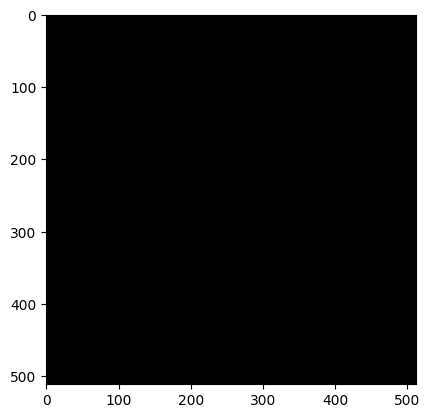

In [ ]:
black_img = np.zeros(shape=(512,512,3), dtype=np.int16)
plt.imshow(black_img)


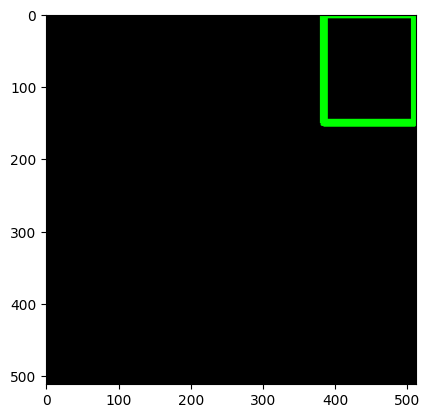

In [ ]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(384,0),pt2=(510,150),color=(0,255,0), thickness=10)
plt.imshow(black_img)

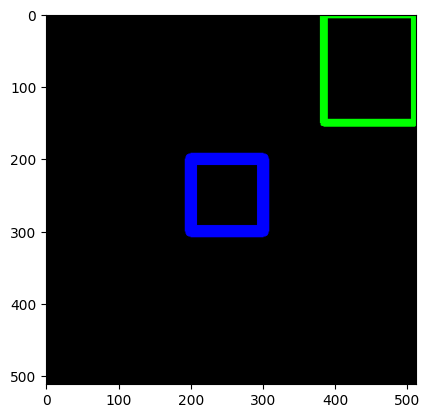

In [ ]:
cv.rectangle(black_img,pt1=(200,200),pt2=(300,300),color=(0,0,255), thickness=15)
plt.imshow(black_img)

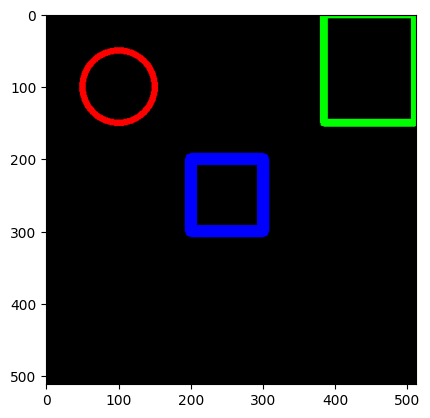

In [ ]:
cv.circle(black_img,center=(100,100),radius=50,color=(255,0,0),thickness=8)
plt.imshow(black_img)

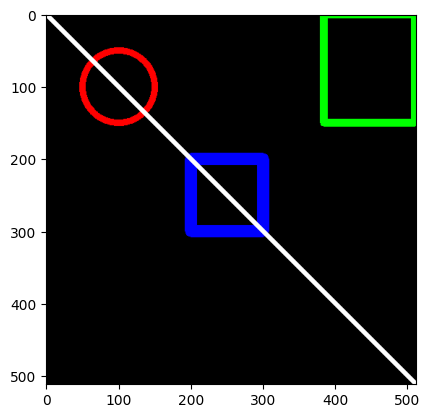

In [ ]:
cv.line(black_img,pt1=(0,0),pt2=(512,512),color=(255,255,255),thickness=5)
plt.imshow(black_img)

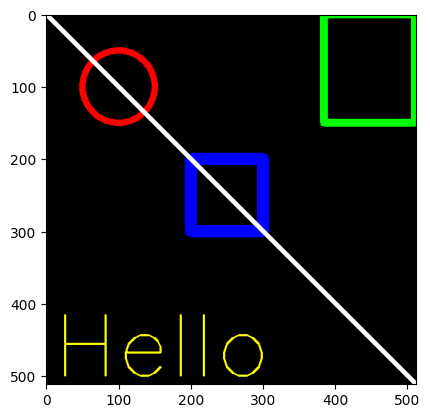

In [ ]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='Hello',org=(10,500),fontFace=font,fontScale=4,color=(255,255,0),thickness=2,lineType=cv.LINE_AA)
plt.imshow(black_img)

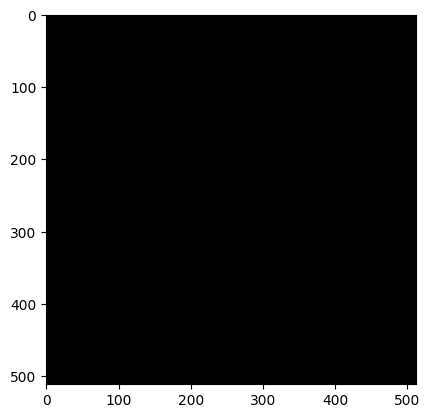

In [ ]:
black_img2=np.zeros(shape=(512,512,3),dtype=np.int32)
plt.imshow(black_img2)

In [ ]:
vertices = np.array([[[100,300],[200,200],[400,300],[200,400]]], dtype=np.int32)
vertices

array([[[100, 300],
        [200, 200],
        [400, 300],
        [200, 400]]], dtype=int32)

In [ ]:
pts = vertices.reshape((-1,1,2)) # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 2 channel yg mewakili x dan y
pts

array([[[100, 300]],

       [[200, 200]],

       [[400, 300]],

       [[200, 400]]], dtype=int32)

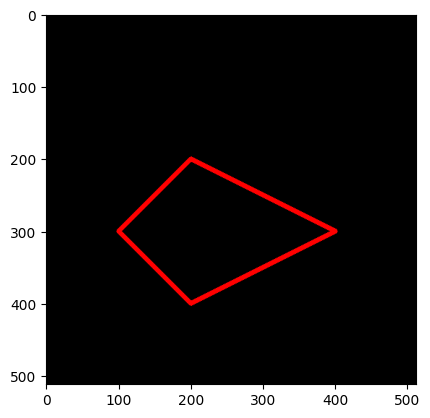

In [ ]:
cv.polylines(black_img2, [pts], isClosed=True, color=(255,0,0), thickness=5)
plt.imshow(black_img2)

# **Task Individu**

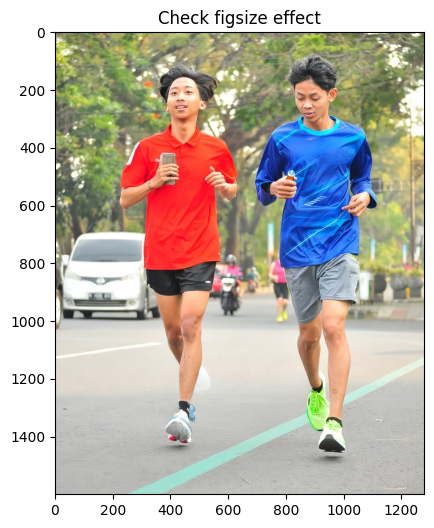

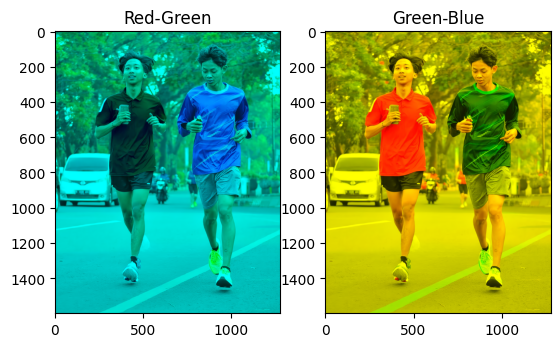

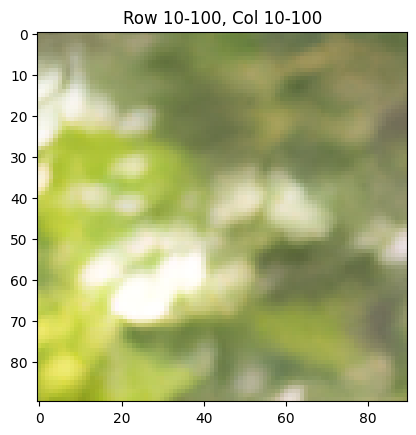

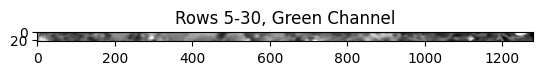

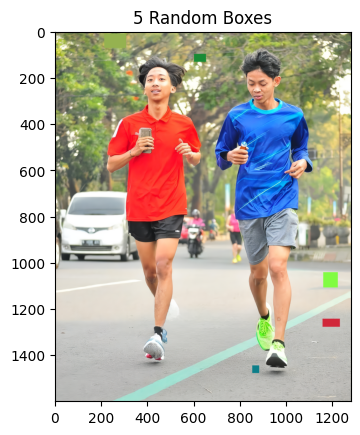

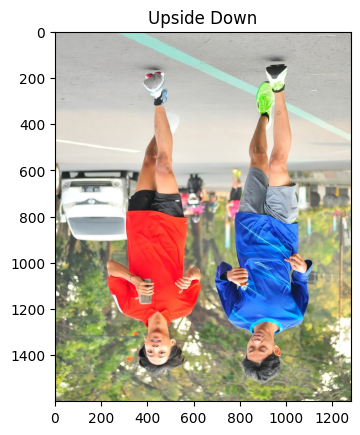

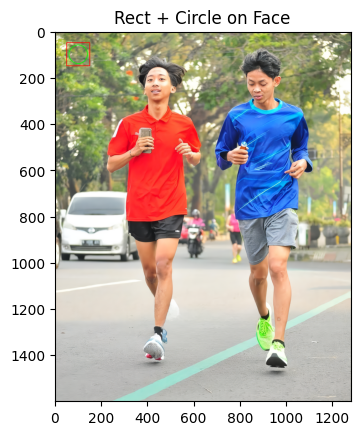

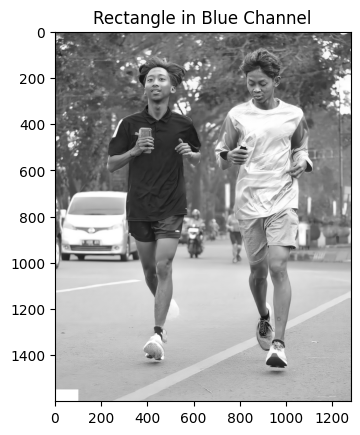

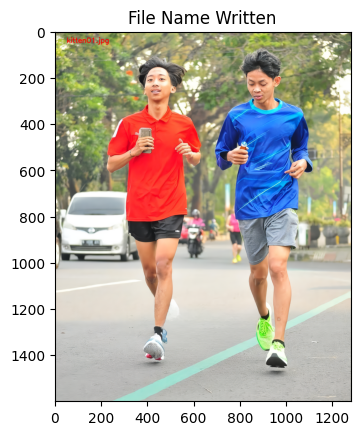

✅ Semua kode sudah ditampilkan dan siap diperiksa oleh dosen.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

img = cv2.imread('/content/drive/MyDrive/Ijen-joging-01-09-2025.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



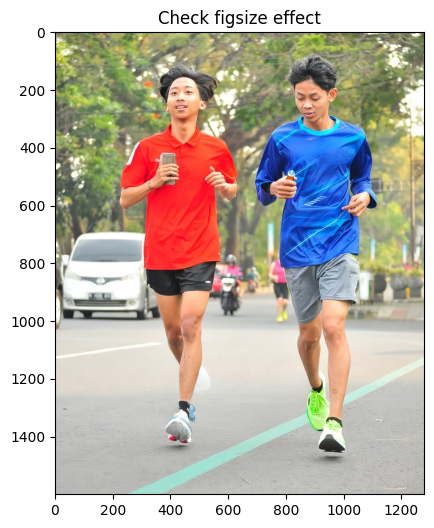

In [ ]:
# 1. By using figsize, notice whether the image pixel size also changes?
plt.figure(figsize=(12,6))
plt.imshow(img_rgb)
plt.title("Check figsize effect")
plt.show()

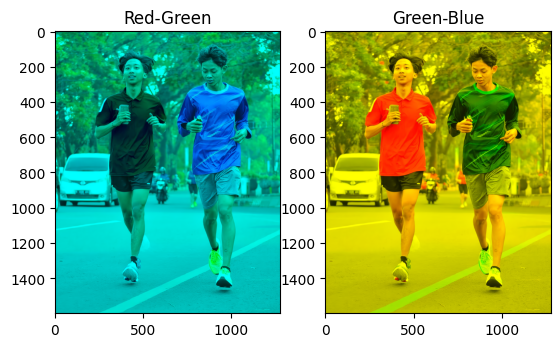

In [ ]:
# 2. Show images in Red-Green and Green-Blue channels only
zeros = np.zeros_like(img_rgb[:,:,0])

RG = cv2.merge([zeros, img_rgb[:,:,1], img_rgb[:,:,2]])  # Red-Green
GB = cv2.merge([img_rgb[:,:,0], img_rgb[:,:,1], zeros])  # Green-Blue

plt.subplot(1,2,1); plt.imshow(RG); plt.title("Red-Green")
plt.subplot(1,2,2); plt.imshow(GB); plt.title("Green-Blue")
plt.show()


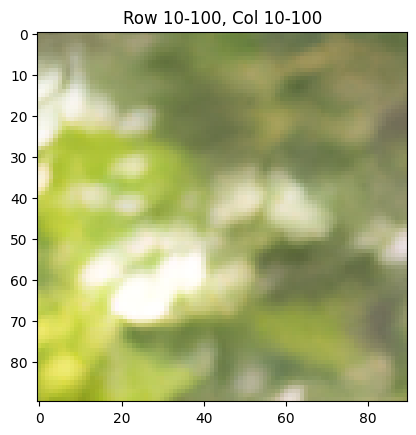

In [ ]:
# 3. Show image row 10-100, column 10-100
crop1 = img_rgb[10:100, 10:100]
plt.imshow(crop1); plt.title("Row 10-100, Col 10-100")
plt.show()

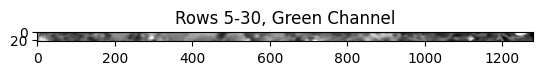

In [ ]:
# 4. Show image rows 5-30, all columns, channel Green only
green_only = img_rgb[5:30, :, 1]
plt.imshow(green_only, cmap='gray'); plt.title("Rows 5-30, Green Channel")
plt.show()

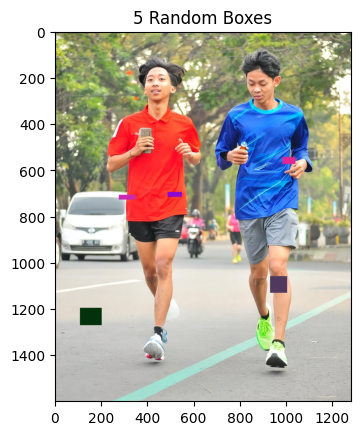

In [ ]:
# 5. Create 5 boxes of different sizes and colors in one image
img_boxes = img_rgb.copy()
for i in range(5):
    x1, y1 = random.randint(0, img_rgb.shape[1]-100), random.randint(0, img_rgb.shape[0]-100)
    x2, y2 = x1 + random.randint(20,100), y1 + random.randint(20,100)
    color = (random.randint(0,255), random.randint(0,255), random.randint(0,255))
    cv2.rectangle(img_boxes, (x1,y1), (x2,y2), color, -1)

plt.imshow(img_boxes); plt.title("5 Random Boxes")
plt.show()

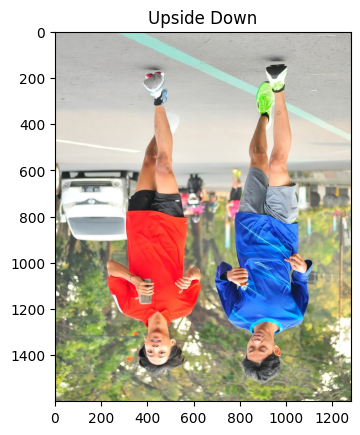

In [ ]:
# 6. Show the image upside down
flip = cv2.flip(img_rgb, 0)
plt.imshow(flip); plt.title("Upside Down")
plt.show()

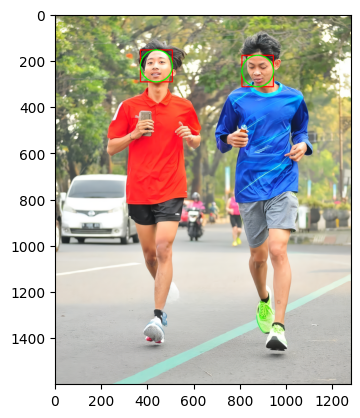

In [ ]:
# 7. Make rectangles and circles on the face of your photo (contoh di kitten/lena)
img_shapes = img_rgb.copy()

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Deteksi wajah
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=7, minSize=(80, 80))

# Loop setiap wajah terdeteksi (hanya 2 terbesar)
for (x, y, w, h) in faces:
    # Kotak
    cv2.rectangle(img_shapes, (x, y), (x+w, y+h), (255,0,0), 3)
    # Lingkaran
    center = (x + w//2, y + h//2)
    radius = max(w, h)//2
    cv2.circle(img_shapes, center, radius, (0,255,0), 3)

plt.imshow(img_shapes)
plt.show()

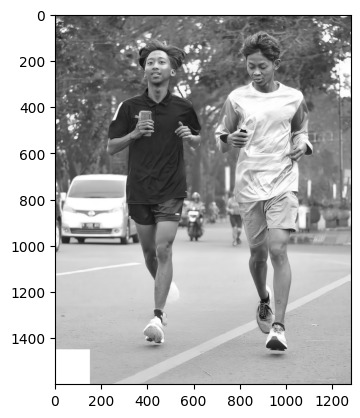

In [ ]:
# 8. Create a square in the lower left corner of channel B
b, g, r = cv2.split(img)

# Tentukan ukuran kotak (misalnya 150x150 px)
size = 150

# Koordinat (x1,y1) kiri-atas dan (x2,y2) kanan-bawah
x1, y1 = 0, b.shape[0] - size
x2, y2 = size, b.shape[0]

# Gambar kotak putih (255) pada channel B
cv2.rectangle(b, (x1, y1), (x2, y2), 255, -1)

# Tampilkan hasil
plt.imshow(b, cmap='gray')
plt.show()



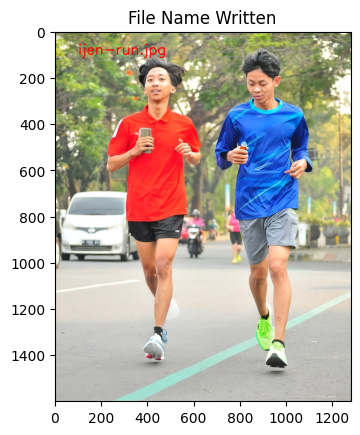

In [ ]:
# 9. Complete the writing of the file name on the image
img_text = img_rgb.copy()
cv2.putText(img_text, "ijen-run.jpg", (100,100), cv2.FONT_HERSHEY_SIMPLEX,
            2, (255,0,0), 3, cv2.LINE_AA)
plt.imshow(img_text); plt.title("File Name Written")
plt.show()


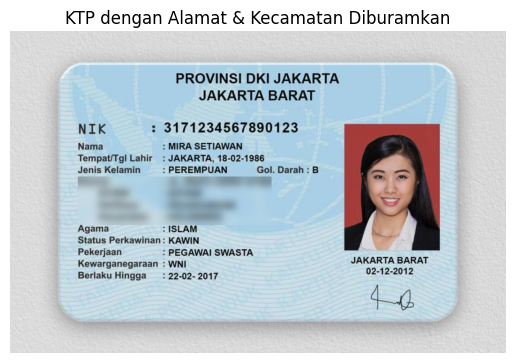

In [10]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/Images/ktp.jpg")

if img is None:
    print("Gambar tidak ditemukan!")
else:
    x, y, w, h = 140, 300, 400, 100
    roi = img[y:y+h, x:x+w]
    roi_blur = cv2.GaussianBlur(roi, (51, 51), 0)
    img[y:y+h, x:x+w] = roi_blur

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title("KTP dengan Alamat & Kecamatan Diburamkan")
    plt.show()

